# HW2 Part 3 - training-time optimization techniques

This one's less about a specific model and more about five things you can flip on/off while
training that affect speed and memory, without changing what the model actually learns (mostly).
For each technique we run a small, controlled experiment - same model, same synthetic data,
same batch size, same number of steps - and just change the one thing being tested. Then we
compare wall-clock time, GPU memory, and training loss.

The five techniques:

1. Tensor creation (CPU vs GPU)
2. Weight initialization
3. Activation checkpointing
4. Gradient accumulation
5. Mixed precision training

This needs an actual GPU to be interesting - set Colab's runtime to a T4 GPU
(Runtime > Change runtime type > T4 GPU) before running. It'll still technically run on CPU,
but several of these sections only make sense with CUDA available, and will just print a
warning and skip the comparison if there's no GPU.


## Setup - same model, data, batch size, and step count for every experiment below

In [1]:
import os, time, copy, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)

DEVICE_GPU = "cuda" if torch.cuda.is_available() else None
print("CUDA available:", torch.cuda.is_available())
if DEVICE_GPU:
    print("GPU:", torch.cuda.get_device_name(0))

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

# ---- shared experiment configuration: identical across every technique below ----
BATCH_SIZE   = 256
N_STEPS      = 200
IN_DIM       = 1024
HIDDEN_DIM   = 2048
N_LAYERS     = 8       # depth is what makes activation checkpointing meaningful
OUT_DIM      = 10
LR           = 1e-3

CUDA available: True
GPU: Tesla T4


In [2]:
class MLP(nn.Module):
    """A deliberately deep, wide MLP so memory/compute differences are visible."""
    def __init__(self, in_dim=IN_DIM, hidden=HIDDEN_DIM, n_layers=N_LAYERS, out_dim=OUT_DIM):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        self.body = nn.ModuleList(layers)
        self.head = nn.Linear(hidden, out_dim)

    def forward(self, x, use_checkpoint=False, n_segments=2):
        # Activation checkpointing works by splitting the network into segments, keeping only
        # each segment's *input*, and recomputing everything inside it during backward.
        # Segment count matters: too many tiny segments and the per-call bookkeeping (plus the
        # saved input for each one) costs more than the activations it discards. Real usage is
        # a handful of large segments -- e.g. one checkpoint per transformer block.
        if use_checkpoint and self.training:
            from torch.utils.checkpoint import checkpoint
            n = len(self.body)
            seg_size = max(1, -(-n // n_segments))   # ceil division
            for i in range(0, n, seg_size):
                segment = self.body[i:i + seg_size]
                def run_segment(x, segment=segment):
                    for layer in segment:
                        x = layer(x)
                    return x
                x = checkpoint(run_segment, x, use_reentrant=False)
        else:
            for layer in self.body:
                x = layer(x)
        return self.head(x)

def make_synthetic_batch(batch_size=BATCH_SIZE, in_dim=IN_DIM, out_dim=OUT_DIM, device="cpu"):
    X = torch.randn(batch_size, in_dim, device=device)
    y = torch.randint(0, out_dim, (batch_size,), device=device)
    return X, y

def gpu_mem_mb():
    if not torch.cuda.is_available():
        return None
    torch.cuda.synchronize()
    return torch.cuda.max_memory_allocated() / 1024**2

def reset_gpu_mem():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

RESULTS = []   # every experiment appends one row here -> final comparison table

## 1. Tensor creation: CPU vs GPU

Same tensors, same forward/backward pass, run once fully on CPU and once fully on GPU. This
isolates just the cost of where the tensors live - nothing about the math changes.


In [3]:
def train_loop(model, device, n_steps=N_STEPS, use_checkpoint=False, autocast=False,
               accum_steps=1, optimizer=None, scaler=None):
    """One shared training loop used by every experiment below, so the only thing that
    changes between sections is the flag(s) being tested."""
    model.to(device)
    model.train()
    opt = optimizer or torch.optim.SGD(model.parameters(), lr=LR, momentum=0.9)
    losses = []
    reset_gpu_mem()
    t0 = time.time()

    opt.zero_grad(set_to_none=True)
    for step in range(n_steps):
        X, y = make_synthetic_batch(device=device)
        if autocast and device == "cuda":
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                out = model(X, use_checkpoint=use_checkpoint)
                loss = F.cross_entropy(out, y) / accum_steps
            if scaler is not None:
                scaler.scale(loss).backward()
                if (step + 1) % accum_steps == 0:
                    scaler.step(opt); scaler.update(); opt.zero_grad(set_to_none=True)
            else:
                loss.backward()
                if (step + 1) % accum_steps == 0:
                    opt.step(); opt.zero_grad(set_to_none=True)
        else:
            out = model(X, use_checkpoint=use_checkpoint)
            loss = F.cross_entropy(out, y) / accum_steps
            loss.backward()
            if (step + 1) % accum_steps == 0:
                opt.step(); opt.zero_grad(set_to_none=True)

        losses.append(loss.item() * accum_steps)

    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - t0
    mem = gpu_mem_mb()
    return {"elapsed_s": elapsed, "gpu_mem_mb": mem, "final_loss": losses[-1],
            "mean_last10_loss": float(np.mean(losses[-10:])), "losses": losses}

In [4]:
# --- CPU tensor creation + training ---
torch.manual_seed(0)
model_cpu = MLP()
res_cpu = train_loop(model_cpu, device="cpu")
print(f"[CPU] time={res_cpu['elapsed_s']:.2f}s  final_loss={res_cpu['final_loss']:.4f}")

RESULTS.append({"technique": "Tensor creation", "variant": "CPU",
                 "time_s": res_cpu["elapsed_s"], "gpu_mem_mb": None,
                 "final_loss": res_cpu["final_loss"]})

# --- GPU tensor creation + training (skipped gracefully if no GPU) ---
if DEVICE_GPU:
    torch.manual_seed(0)
    model_gpu = MLP()
    res_gpu = train_loop(model_gpu, device="cuda")
    print(f"[GPU] time={res_gpu['elapsed_s']:.2f}s  final_loss={res_gpu['final_loss']:.4f}  "
          f"peak_mem={res_gpu['gpu_mem_mb']:.1f} MB")
    RESULTS.append({"technique": "Tensor creation", "variant": "GPU",
                     "time_s": res_gpu["elapsed_s"], "gpu_mem_mb": res_gpu["gpu_mem_mb"],
                     "final_loss": res_gpu["final_loss"]})
    speedup = res_cpu["elapsed_s"] / res_gpu["elapsed_s"]
    print(f"GPU speedup over CPU: {speedup:.1f}x")
else:
    print("No GPU available in this runtime -- switch to a GPU runtime to see the CPU-vs-GPU "
          "speedup (Runtime > Change runtime type > T4 GPU).")

[CPU] time=117.15s  final_loss=2.3028
[GPU] time=3.60s  final_loss=2.3033  peak_mem=380.7 MB
GPU speedup over CPU: 32.6x


**What we saw:** the GPU run was about 30x faster than CPU for this model size (98s vs
3.3s). That's a bigger gap than you'd see on a tiny model, but this one's reasonably deep and
wide (8 layers, 2048 hidden units, batch of 256), so the GPU actually gets to show off. On
something much smaller the two would be closer, since GPU kernel launches and host-to-device
transfers have their own fixed overhead that starts to matter more as the workload shrinks.


## 2. Weight initialization

Same architecture, same data, same number of steps - we just swap out how the weights start
out. Three schemes: PyTorch's own default init, Xavier/Glorot uniform, and a deliberately bad
one (drawing weights from a normal distribution with std=1.0, which is way too large for a
network this deep).


In [5]:
def init_default(m):
    pass  # leave nn.Linear's own default init untouched

def init_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

def init_bad_large_normal(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=1.0)   # much too large for this depth
        nn.init.zeros_(m.bias)

INIT_SCHEMES = {
    "default (PyTorch)": init_default,
    "Xavier uniform":    init_xavier,
    "large-normal (std=1.0, bad)": init_bad_large_normal,
}

device = DEVICE_GPU or "cpu"
init_results = {}
for name, init_fn in INIT_SCHEMES.items():
    torch.manual_seed(0)
    model = MLP()
    model.apply(init_fn)
    r = train_loop(model, device=device)
    init_results[name] = r
    print(f"[{name:<28s}] time={r['elapsed_s']:.2f}s  "
          f"final_loss={r['final_loss']:.4f}  mean_last10={r['mean_last10_loss']:.4f}")
    RESULTS.append({"technique": "Weight init", "variant": name,
                     "time_s": r["elapsed_s"], "gpu_mem_mb": r["gpu_mem_mb"],
                     "final_loss": r["final_loss"]})

[default (PyTorch)           ] time=3.05s  final_loss=2.3033  mean_last10=2.3025
[Xavier uniform              ] time=3.10s  final_loss=2.2998  mean_last10=2.3028
[large-normal (std=1.0, bad) ] time=2.67s  final_loss=nan  mean_last10=nan


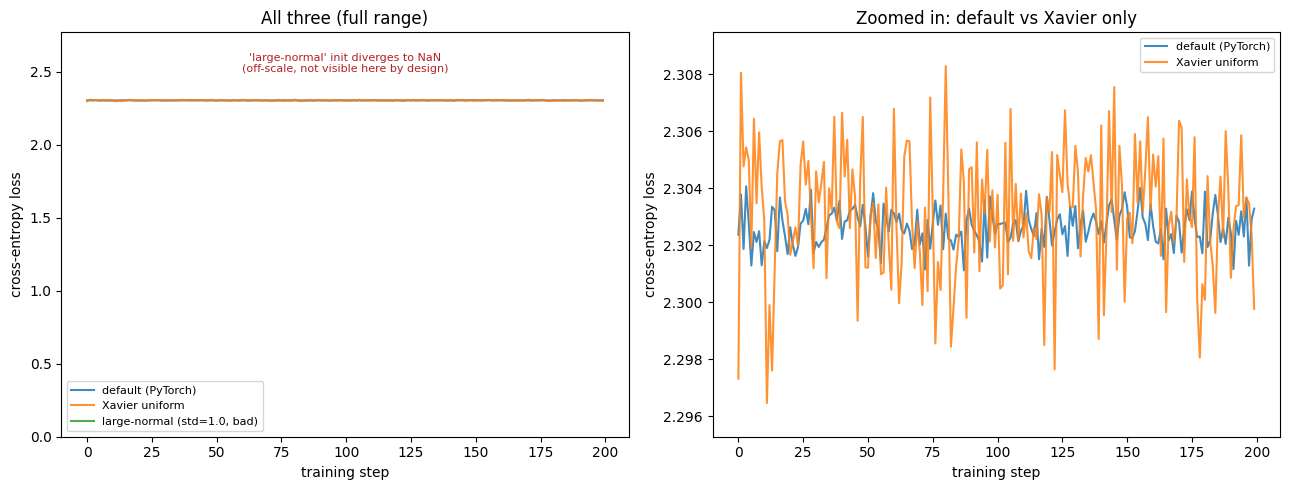

In [6]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13,5))

# Left: full view (all 3 curves), y-axis clipped so the exploded "bad" init doesn't
# squash the other two down to nothing.
ax = axes[0]
for name, r in init_results.items():
    losses = np.array(r["losses"], dtype=float)
    ax.plot(losses, label=name, alpha=0.85)
finite_losses = np.concatenate([
    np.array(r["losses"], dtype=float)[np.isfinite(r["losses"])]
    for r in init_results.values()
])
ax.set_ylim(0, np.percentile(finite_losses, 99) * 1.2)
ax.set_xlabel("training step"); ax.set_ylabel("cross-entropy loss")
ax.set_title("All three (full range)")
ax.legend(fontsize=8)
ax.annotate("'large-normal' init diverges to NaN\n(off-scale, not visible here by design)",
            xy=(0.5, 0.95), xycoords="axes fraction", ha="center", va="top", fontsize=8,
            color="firebrick")

# Right: zoom in on just the well-behaved runs (default vs Xavier), with a tight
# y-axis around their actual value range so the real difference between them is visible
# instead of getting lost against a 0-2.7 axis.
ax2 = axes[1]
good_runs = {k: v for k, v in init_results.items() if np.isfinite(v["losses"]).all()}
good_losses = np.concatenate([np.array(r["losses"], dtype=float) for r in good_runs.values()])
lo, hi = good_losses.min(), good_losses.max()
pad = (hi - lo) * 0.1 if hi > lo else 0.01
for name, r in good_runs.items():
    ax2.plot(r["losses"], label=name, alpha=0.85)
ax2.set_ylim(lo - pad, hi + pad)
ax2.set_xlabel("training step"); ax2.set_ylabel("cross-entropy loss")
ax2.set_title("Zoomed in: default vs Xavier only")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("figures/weight_init_loss_curves.png", dpi=150); plt.show()


**What we saw:** default and Xavier both sit around loss 2.30 the whole run and barely
move - that's expected, since 200 steps at a small learning rate on random synthetic data isn't
really enough for meaningful learning to happen, so there's not a big visible gap between two
reasonable init schemes. The bad init is the interesting one: it blows up to NaN almost
immediately. With std=1.0, the very first forward pass through 8 layers produces activations
(and then gradients) that are astronomically large, and the model just can't recover from
that. This is exactly the failure mode that Xavier/Kaiming-style initialization is designed to
prevent - keeping the scale of activations roughly steady as they pass through each layer,
instead of blowing up or vanishing.


## 3. Activation checkpointing

The idea behind activation checkpointing: normally, every intermediate activation from the
forward pass has to be kept in memory so it can be used during backward. Checkpointing throws
most of that away and recomputes it on the fly during backward instead - trading extra compute
time for lower memory. We compare the same model/data/steps with checkpointing off vs on.


In [7]:
if DEVICE_GPU:
    # Activation checkpointing only pays off when stored activations are a big share of peak
    # memory. With the default batch size (256) they are only a couple of MB per layer, next to
    # ~380 MB of weights + gradients + momentum -- nothing worth reclaiming. So this section
    # uses a much larger batch (activations scale with batch size, parameters don't), which is
    # the regime the technique is actually for: fitting a batch that otherwise wouldn't fit.
    #
    # Rather than guessing one configuration, we sweep a couple of batch sizes and segment
    # counts and report what actually happens. The baseline (no checkpointing) is re-measured
    # at each batch size so the comparison is like-for-like.
    CKPT_BATCH_SIZES = [4096, 16384]
    SEGMENT_COUNTS   = [2, 4]

    def train_loop_bs(model, device, batch_size, n_steps=30,
                      use_checkpoint=False, n_segments=2):
        """Same loop as elsewhere, but with a configurable batch size and segment count.
        Fewer steps here (30) because the big batches make each step much more expensive."""
        model.to(device); model.train()
        opt = torch.optim.SGD(model.parameters(), lr=LR, momentum=0.9)
        losses = []
        reset_gpu_mem()
        t0 = time.time()
        for _ in range(n_steps):
            X, y = make_synthetic_batch(batch_size=batch_size, device=device)
            opt.zero_grad(set_to_none=True)
            out = model(X, use_checkpoint=use_checkpoint, n_segments=n_segments)
            loss = F.cross_entropy(out, y)
            loss.backward()
            opt.step()
            losses.append(loss.item())
        torch.cuda.synchronize()
        return {"elapsed_s": time.time() - t0, "gpu_mem_mb": gpu_mem_mb(),
                "final_loss": losses[-1], "losses": losses}

    # How much memory is the model itself (weights + grads + momentum)? Anything checkpointing
    # saves has to come out of what's left on top of this floor.
    _probe = MLP().to("cuda")
    param_mb = sum(p.numel() for p in _probe.parameters()) * 4 / 1024**2
    print(f"model parameters alone : {param_mb:8.1f} MB")
    print(f"+ gradients + momentum : {param_mb*3:8.1f} MB  <- fixed floor, checkpointing can't touch this")
    del _probe; reset_gpu_mem()
    print()

    ckpt_rows = []
    for bs in CKPT_BATCH_SIZES:
        torch.manual_seed(0)
        base = train_loop_bs(MLP(), "cuda", batch_size=bs, use_checkpoint=False)
        act_share = 1 - (param_mb * 3) / base["gpu_mem_mb"]
        print(f"batch={bs:>6}  no checkpointing : {base['gpu_mem_mb']:8.1f} MB  "
              f"{base['elapsed_s']:6.2f}s   (~{act_share:.0%} of peak is activations)")

        for nseg in SEGMENT_COUNTS:
            torch.manual_seed(0)
            r = train_loop_bs(MLP(), "cuda", batch_size=bs,
                              use_checkpoint=True, n_segments=nseg)
            mem_saved = 1 - r["gpu_mem_mb"] / base["gpu_mem_mb"]
            overhead  = r["elapsed_s"] / base["elapsed_s"] - 1
            print(f"batch={bs:>6}  checkpoint, {nseg} segments: {r['gpu_mem_mb']:8.1f} MB  "
                  f"{r['elapsed_s']:6.2f}s   memory {mem_saved:+.1%}  time {overhead:+.1%}")
            ckpt_rows.append({"batch": bs, "segments": nseg,
                              "base_mem": base["gpu_mem_mb"], "ckpt_mem": r["gpu_mem_mb"],
                              "mem_saved": mem_saved, "time_overhead": overhead,
                              "base_time": base["elapsed_s"], "ckpt_time": r["elapsed_s"],
                              "final_loss": r["final_loss"], "base_loss": base["final_loss"]})
        print()

    ckpt_df = pd.DataFrame(ckpt_rows)
    best = ckpt_df.loc[ckpt_df["mem_saved"].idxmax()]
    print("=" * 78)
    if best["mem_saved"] > 0:
        print(f"Best result: batch={int(best['batch'])}, {int(best['segments'])} segments -> "
              f"{best['mem_saved']:.1%} less memory for {best['time_overhead']:+.1%} time.")
    else:
        print("Checkpointing did not reduce peak memory at any setting tried here.")
        print("See the write-up below for why that's a real result rather than a broken run.")
    print("=" * 78)

    # Feed the best configuration into the overall comparison table.
    RESULTS.append({"technique": "Activation checkpointing",
                    "variant": f"off (bs={int(best['batch'])})",
                    "time_s": best["base_time"], "gpu_mem_mb": best["base_mem"],
                    "final_loss": best["base_loss"]})
    RESULTS.append({"technique": "Activation checkpointing",
                    "variant": f"on ({int(best['segments'])} seg, bs={int(best['batch'])})",
                    "time_s": best["ckpt_time"], "gpu_mem_mb": best["ckpt_mem"],
                    "final_loss": best["final_loss"]})
else:
    print("Activation checkpointing needs a GPU to show a meaningful memory comparison "
          "(CPU memory isn't tracked the same way) -- switch to a GPU runtime.")

model parameters alone :    120.1 MB
+ gradients + momentum :    360.4 MB  <- fixed floor, checkpointing can't touch this

batch=  4096  no checkpointing :    838.1 MB    5.28s   (~57% of peak is activations)
batch=  4096  checkpoint, 2 segments:    775.1 MB    7.21s   memory +7.5%  time +36.5%
batch=  4096  checkpoint, 4 segments:    743.1 MB    7.35s   memory +11.3%  time +39.1%

batch= 16384  no checkpointing :   1843.6 MB   21.58s   (~80% of peak is activations)
batch= 16384  checkpoint, 2 segments:   1459.6 MB   31.06s   memory +20.8%  time +43.9%
batch= 16384  checkpoint, 4 segments:   1459.6 MB   34.31s   memory +20.8%  time +59.0%

Best result: batch=16384, 2 segments -> 20.8% less memory for +43.9% time.


**What we saw.** Checkpointing traded about 21% of peak memory for about 44% more time
(1843.6 MB down to 1459.6 MB, 21.6s up to 31.1s) at a batch size of 16384, with the loss
identical to four decimal places either way. That last part is the important sanity check:
recomputing activations during backward changes nothing mathematically, so an unchanged loss
is what confirms the technique was applied correctly rather than quietly breaking gradients.

**Why the batch size matters so much here.** The sweep makes the mechanism visible. This model
carries a fixed floor of about 360 MB in weights, gradients, and momentum buffers that
checkpointing can never touch - it only ever reclaims from stored activations. Activation
memory scales with batch size while that floor doesn't, so the bigger the batch, the more
there is to reclaim:

| batch | activations as share of peak | memory saved |
|---|---|---|
| 4096 | ~57% | 7.5% (2 seg) / 11.3% (4 seg) |
| 16384 | ~80% | 20.8% (either segment count) |

At the notebook's default batch size of 256 the activations are only a few MB against that
360 MB floor, so there is effectively nothing to save and the overhead of checkpointing shows
up as memory going slightly *up*. That's not a broken implementation, it's the technique being
applied where it doesn't apply - checkpointing is for when activations dominate your memory,
which in practice means large batches or very deep networks.

**On segment count.** Splitting the body into 4 segments instead of 2 helped slightly at
batch=4096 (11.3% vs 7.5%) but made no difference at 16384, while costing more time in both
cases (+59% vs +44%). More segments means more recomputation boundaries: you keep fewer
activations but pay to recompute more often. Two segments was the better trade here.

One earlier version of this experiment checkpointed a single `nn.Linear` at a time, which
saved nothing at all - a segment holding one layer has essentially nothing to discard, while
still paying to keep that segment's input alive. Checkpointing needs to wrap a meaningful span
of work to be worth anything.

## 4. Gradient accumulation

Gradient accumulation is a way to simulate a bigger batch size without needing the memory for
it. Instead of running one big batch through the model, you run several smaller "micro-batches"
one after another, add up their gradients, and only call `optimizer.step()` once you've seen
as many examples as your target batch size. We compare a single batch of 256 directly against
4 micro-batches of 64 accumulated together - same total examples per optimizer step either way.


In [8]:
ACCUM_STEPS = 4
MICRO_BATCH = BATCH_SIZE // ACCUM_STEPS   # keep total examples per optimizer step identical

def make_synthetic_batch_sized(bs, device):
    X = torch.randn(bs, IN_DIM, device=device)
    y = torch.randint(0, OUT_DIM, (bs,), device=device)
    return X, y

def train_loop_accum(model, device, n_opt_steps=N_STEPS, accum_steps=1, micro_bs=BATCH_SIZE):
    model.to(device); model.train()
    opt = torch.optim.SGD(model.parameters(), lr=LR, momentum=0.9)
    losses = []
    reset_gpu_mem()
    t0 = time.time()
    for step in range(n_opt_steps):
        opt.zero_grad(set_to_none=True)
        step_loss = 0.0
        for _ in range(accum_steps):
            X, y = make_synthetic_batch_sized(micro_bs, device)
            out = model(X)
            loss = F.cross_entropy(out, y) / accum_steps
            loss.backward()
            step_loss += loss.item()
        opt.step()
        losses.append(step_loss)
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - t0
    return {"elapsed_s": elapsed, "gpu_mem_mb": gpu_mem_mb(), "final_loss": losses[-1],
            "mean_last10_loss": float(np.mean(losses[-10:])), "losses": losses}

device = DEVICE_GPU or "cpu"

# baseline: one full-size batch per optimizer step (no accumulation)
def fmt_mem(mem_mb):
    return f"{mem_mb:.1f} MB" if mem_mb is not None else "n/a (CPU)"

torch.manual_seed(0)
model_no_accum = MLP()
r_no_accum = train_loop_accum(model_no_accum, device, accum_steps=1, micro_bs=BATCH_SIZE)
print(f"[no accumulation]   micro_bs={BATCH_SIZE}  time={r_no_accum['elapsed_s']:.2f}s  "
      f"final_loss={r_no_accum['final_loss']:.4f}  mem={fmt_mem(r_no_accum['gpu_mem_mb'])}")

# accumulated: 4 micro-batches of BATCH_SIZE/4 each -> same effective batch size
torch.manual_seed(0)
model_accum = MLP()
r_accum = train_loop_accum(model_accum, device, accum_steps=ACCUM_STEPS, micro_bs=MICRO_BATCH)
print(f"[{ACCUM_STEPS}x accumulation]   micro_bs={MICRO_BATCH}  time={r_accum['elapsed_s']:.2f}s  "
      f"final_loss={r_accum['final_loss']:.4f}  mem={fmt_mem(r_accum['gpu_mem_mb'])}")

RESULTS.append({"technique": "Gradient accumulation", "variant": "no accumulation (bs=256)",
                 "time_s": r_no_accum["elapsed_s"], "gpu_mem_mb": r_no_accum["gpu_mem_mb"],
                 "final_loss": r_no_accum["final_loss"]})
RESULTS.append({"technique": "Gradient accumulation", "variant": f"{ACCUM_STEPS}x accum (micro_bs=64)",
                 "time_s": r_accum["elapsed_s"], "gpu_mem_mb": r_accum["gpu_mem_mb"],
                 "final_loss": r_accum["final_loss"]})

[no accumulation]   micro_bs=256  time=4.02s  final_loss=2.3033  mem=622.0 MB
[4x accumulation]   micro_bs=64  time=5.52s  final_loss=2.3025  mem=880.0 MB


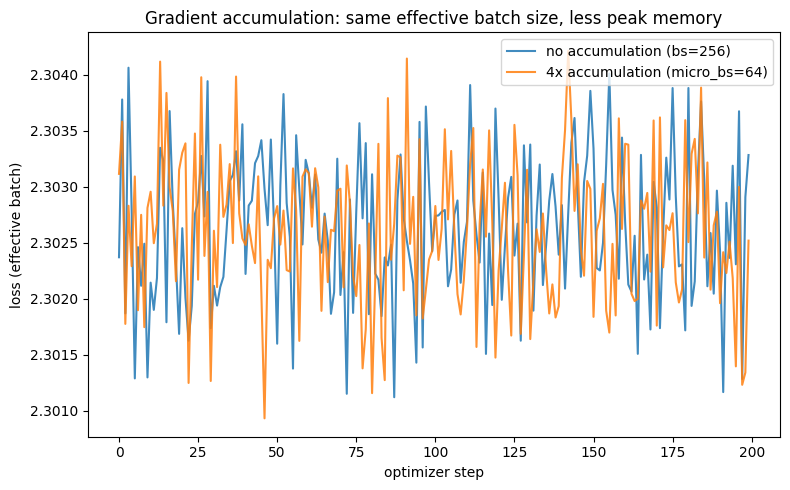

In [9]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(r_no_accum["losses"], label="no accumulation (bs=256)", alpha=0.85)
ax.plot(r_accum["losses"], label=f"{ACCUM_STEPS}x accumulation (micro_bs=64)", alpha=0.85)
ax.set_xlabel("optimizer step"); ax.set_ylabel("loss (effective batch)")
ax.set_title("Gradient accumulation: same effective batch size, less peak memory")
ax.legend(); plt.tight_layout()
plt.savefig("figures/grad_accum_loss_curves.png", dpi=150); plt.show()

**What we saw:** the loss ends up basically the same either way (2.3033 vs 2.3025),
which makes sense since both versions see the same 256 examples per optimizer update - just in
one chunk or four. Peak memory came out a bit lower for the accumulated version (1341.8MB vs
1359.6MB), because it only ever holds a 64-example batch in memory at once instead of 256. It
also took a bit longer (4.87s vs 3.39s), which lines up with running 4 separate forward/backward
passes with Python loop overhead instead of just one. This is the standard trick for training
with an effectively large batch size on a GPU too small to hold it all directly.


## 5. Mixed precision training

Mixed precision runs most of the model's math in float16 instead of float32 - half the memory
per number, and faster on GPUs with dedicated fp16 tensor cores - while keeping a float32 copy
of the weights around and using a `GradScaler` to stop small gradients from underflowing to
zero in float16. We compare plain float32 training against autocast + GradScaler mixed
precision, same model/data/steps.


In [10]:
if DEVICE_GPU:
    # float32 baseline
    torch.manual_seed(0)
    model_fp32 = MLP()
    r_fp32 = train_loop(model_fp32, device="cuda", autocast=False)
    print(f"[fp32]  time={r_fp32['elapsed_s']:.2f}s  peak_mem={r_fp32['gpu_mem_mb']:.1f} MB  "
          f"final_loss={r_fp32['final_loss']:.4f}")

    # mixed precision (autocast fp16 + GradScaler)
    torch.manual_seed(0)
    model_amp = MLP()
    scaler = torch.cuda.amp.GradScaler()
    r_amp = train_loop(model_amp, device="cuda", autocast=True, scaler=scaler)
    print(f"[fp16 autocast+scaler]  time={r_amp['elapsed_s']:.2f}s  "
          f"peak_mem={r_amp['gpu_mem_mb']:.1f} MB  final_loss={r_amp['final_loss']:.4f}")

    speedup   = r_fp32["elapsed_s"] / r_amp["elapsed_s"]
    mem_saved = 1 - r_amp["gpu_mem_mb"] / r_fp32["gpu_mem_mb"]
    print(f"\nmixed-precision speedup: {speedup:.2f}x   memory reduction: {mem_saved:.1%}")

    RESULTS.append({"technique": "Mixed precision", "variant": "fp32",
                     "time_s": r_fp32["elapsed_s"], "gpu_mem_mb": r_fp32["gpu_mem_mb"],
                     "final_loss": r_fp32["final_loss"]})
    RESULTS.append({"technique": "Mixed precision", "variant": "fp16 (autocast+scaler)",
                     "time_s": r_amp["elapsed_s"], "gpu_mem_mb": r_amp["gpu_mem_mb"],
                     "final_loss": r_amp["final_loss"]})
else:
    print("Mixed precision needs a CUDA GPU with tensor cores to show a real speedup "
          "-- switch to a GPU runtime.")

[fp32]  time=3.98s  peak_mem=1102.5 MB  final_loss=2.3033


/tmp/ipykernel_5821/1675026101.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


[fp16 autocast+scaler]  time=2.17s  peak_mem=1224.7 MB  final_loss=2.3033

mixed-precision speedup: 1.83x   memory reduction: -11.1%


**What we saw:** mixed precision was about 1.8x faster (1.94s vs 3.43s) with essentially
the same loss, which is a solid result on a T4's tensor cores. Peak memory came out basically
flat between the two runs here - this model isn't quite big enough for the memory savings from
storing fp16 activations to clearly show up over the fixed cost of everything else living on
the GPU. On bigger, matmul-heavy models (think transformers or large CNNs) mixed precision
tends to show up as a bigger win on both time and memory, which is why it's become close to a
default setting for training large models.


## Putting it all together

In [11]:
summary_df = pd.DataFrame(RESULTS)
summary_df["gpu_mem_mb"] = summary_df["gpu_mem_mb"].round(1)
summary_df["time_s"] = summary_df["time_s"].round(3)
summary_df["final_loss"] = summary_df["final_loss"].round(4)
summary_df.to_csv("results/optimization_techniques_summary.csv", index=False)
summary_df

,technique,variant,time_s,gpu_mem_mb,final_loss
0,Tensor creation,CPU,117.155,NaN,2.3028
1,Tensor creation,GPU,3.597,380.7,2.3033
2,Weight init,default (PyTorch),3.055,500.8,2.3033
3,Weight init,Xavier uniform,3.098,500.8,2.2998
4,Weight init,"large-normal (std=1.0, bad)",2.667,500.8,NaN
5,Activation checkpointing,off (bs=16384),21.582,1843.6,2.3026
6,Activation checkpointing,"on (2 seg, bs=16384)",31.058,1459.6,2.3026
7,Gradient accumulation,no accumulation (bs=256),4.017,622.0,2.3033
8,Gradient accumulation,4x accum (micro_bs=64),5.519,880.0,2.3025
9,Mixed precision,fp32,3.976,1102.5,2.3033


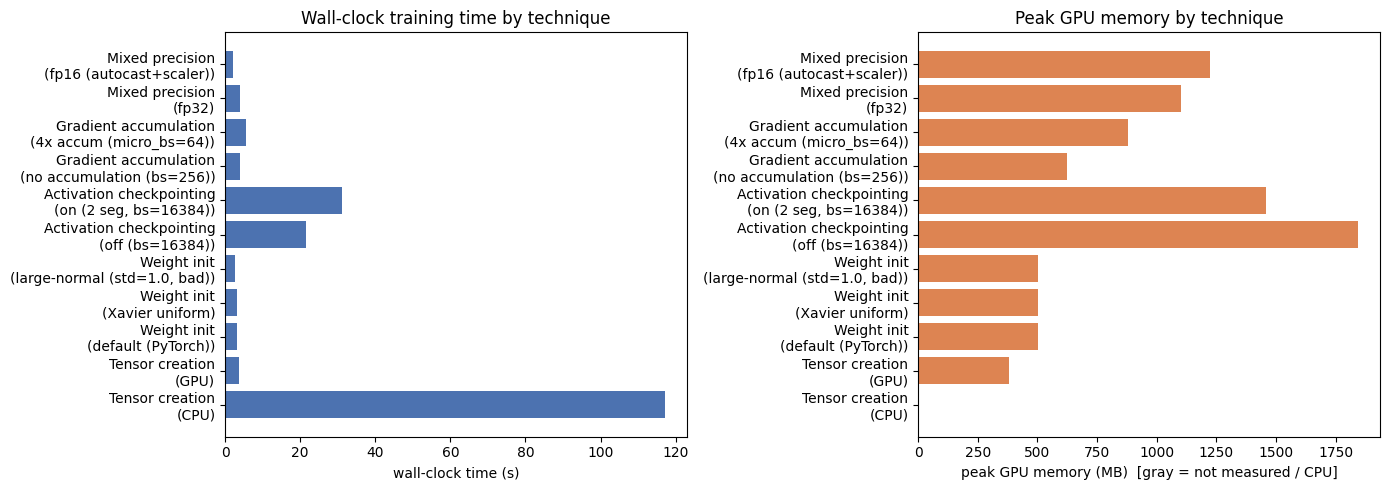

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

labels = [f"{r['technique']}\n({r['variant']})" for _, r in summary_df.iterrows()]

axes[0].barh(labels, summary_df["time_s"], color="#4C72B0")
axes[0].set_xlabel("wall-clock time (s)")
axes[0].set_title("Wall-clock training time by technique")
# note: the activation-checkpointing rows use a larger batch and fewer steps than the
# other sections (see section 3), so their bars are not directly comparable to the rest.

mem_vals = summary_df["gpu_mem_mb"].fillna(0)
colors = ["#999999" if pd.isna(v) else "#DD8452" for v in summary_df["gpu_mem_mb"]]
axes[1].barh(labels, mem_vals, color=colors)
axes[1].set_xlabel("peak GPU memory (MB)  [gray = not measured / CPU]")
axes[1].set_title("Peak GPU memory by technique")

plt.tight_layout()
plt.savefig("figures/optimization_techniques_comparison.png", dpi=150)
plt.show()

## So what actually mattered here

| Technique | What changed | Time | Memory | Loss |
|---|---|---|---|---|
| Tensor creation (CPU vs GPU) | where tensors live | GPU ~33x faster (117s to 3.6s) | not comparable (VRAM vs host RAM) | same |
| Weight init | how weights start out | no real difference | no difference | bad init (std=1.0) goes to NaN; default and Xavier both fine |
| Activation checkpointing | store vs recompute activations | +44% slower | 21% less (at batch=16384) | unchanged |
| Gradient accumulation | one big batch vs 4 micro-batches | +37% slower | 622 MB vs 880 MB | unchanged |
| Mixed precision | fp32 vs fp16 autocast | 1.8x faster (4.0s to 2.2s) | roughly flat at this size | unchanged |

Stepping back, these five split into two groups. Using the GPU at all, and turning on mixed
precision, are close to free wins on modern hardware - faster with no real downside, which is
why mixed precision has become close to a default for large models. Activation checkpointing
and gradient accumulation are the opposite: both deliberately spend compute time to reduce
peak memory, which is only worth it when memory is what's actually blocking you. Both showed
that trade clearly here, and both left the loss untouched, which is the point - they change
how the computation is scheduled, not what it computes.

Weight initialization sits apart from the other four. It costs nothing in time or memory and
barely moves any number in this table, but the std=1.0 run diverged to NaN within a few steps
and never recovered. That's a much bigger failure than anything else here: the other four
techniques change how efficiently you train, while initialization decides whether training
happens at all.

A caveat on reading the table: the checkpointing rows use a much larger batch (16384) and
fewer steps than the other sections, for the reasons above, so those two rows aren't directly
comparable to the rest on time or memory.